# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [57]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# magic word for producing visualizations in notebook
%matplotlib inline

pd.options.display.max_rows = None
pd.options.display.max_columns = None


### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [58]:
# Load in the general demographics data.

# Load in the feature summary file and store it to a variable
# named `feat_info`.
azdias = pd.read_csv('Udacity_AZDIAS_Subset.csv', delimiter=';')
customers = pd.read_csv('Udacity_CUSTOMERS_Subset.csv', delimiter=';')
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', delimiter=';')



In [59]:
# Check the structure of the data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).

# Quick check
print(azdias.shape)
print(customers.shape)
print(feat_info.head())


(891221, 85)
(191652, 85)
              attribute information_level         type missing_or_unknown
0              AGER_TYP            person  categorical             [-1,0]
1  ALTERSKATEGORIE_GROB            person      ordinal           [-1,0,9]
2             ANREDE_KZ            person  categorical             [-1,0]
3         CJT_GESAMTTYP            person  categorical                [0]
4     FINANZ_MINIMALIST            person      ordinal               [-1]


> **Tip**: Add additional cells to keep everything in reasonably-sized chunks! Keyboard shortcut `esc --> a` (press escape to enter command mode, then press the 'A' key) adds a new cell before the active cell, and `esc --> b` adds a new cell after the active cell. If you need to convert an active cell to a markdown cell, use `esc --> m` and to convert to a code cell, use `esc --> y`. 

## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [60]:
# Identify missing or unknown data values and convert them to NaNs.
import ast

def convert_missing_to_nan_safe(df, feat_info):
    """
    Convert missing/unknown value codes to NaN using ast.literal_eval
    """
    df_clean = df.copy()
    
    for col in df_clean.columns:
        missing_row = feat_info.loc[feat_info['attribute'] == col, 'missing_or_unknown']
        
        if len(missing_row) > 0:
            missing_val = missing_row.values[0]
            
            if pd.isna(missing_val) or missing_val == '':
                continue
            
            try:
                # Try to parse as Python literal (list)
                if isinstance(missing_val, str):
                    missing_list = ast.literal_eval(missing_val)
                else:
                    missing_list = missing_val
                
                # Convert to numeric values only
                missing_numeric = []
                for v in missing_list:
                    if isinstance(v, (int, float)):
                        missing_numeric.append(float(v))
                
                if missing_numeric:
                    df_clean[col] = df_clean[col].replace(missing_numeric, np.nan)
            except (SyntaxError, ValueError, TypeError):
                # If parsing fails, skip this column
                continue
    
    return df_clean

# Apply safe version
azdias = convert_missing_to_nan_safe(azdias, feat_info)
customers = convert_missing_to_nan_safe(customers, feat_info)

#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

In [61]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.
missing_percentage = (azdias.isnull().sum() / len(azdias)) * 100

missing_percentage_sorted = missing_percentage.sort_values(ascending=False)
print("Columns with missing data (top 20):")
print(missing_percentage_sorted.head(20))
print(f"\nTotal columns: {len(missing_percentage)}")
print(f"Columns with any missing data: {(missing_percentage > 0).sum()}")
print(f"Columns with >30% missing data: {(missing_percentage > 30).sum()}")


Columns with missing data (top 20):
TITEL_KZ          99.757636
AGER_TYP          76.955435
KK_KUNDENTYP      65.596749
KBA05_BAUMAX      53.468668
GEBURTSJAHR       44.020282
ALTER_HH          34.813699
KKK               17.735668
REGIOTYP          17.735668
W_KEIT_KIND_HH    16.605084
KBA05_ANTG1       14.959701
KBA05_ANTG2       14.959701
KBA05_ANTG3       14.959701
KBA05_ANTG4       14.959701
KBA05_GBZ         14.959701
MOBI_REGIO        14.959701
PLZ8_ANTG3        13.073637
PLZ8_ANTG2        13.073637
PLZ8_GBZ          13.073637
PLZ8_HHZ          13.073637
PLZ8_ANTG1        13.073637
dtype: float64

Total columns: 85
Columns with any missing data: 61
Columns with >30% missing data: 6


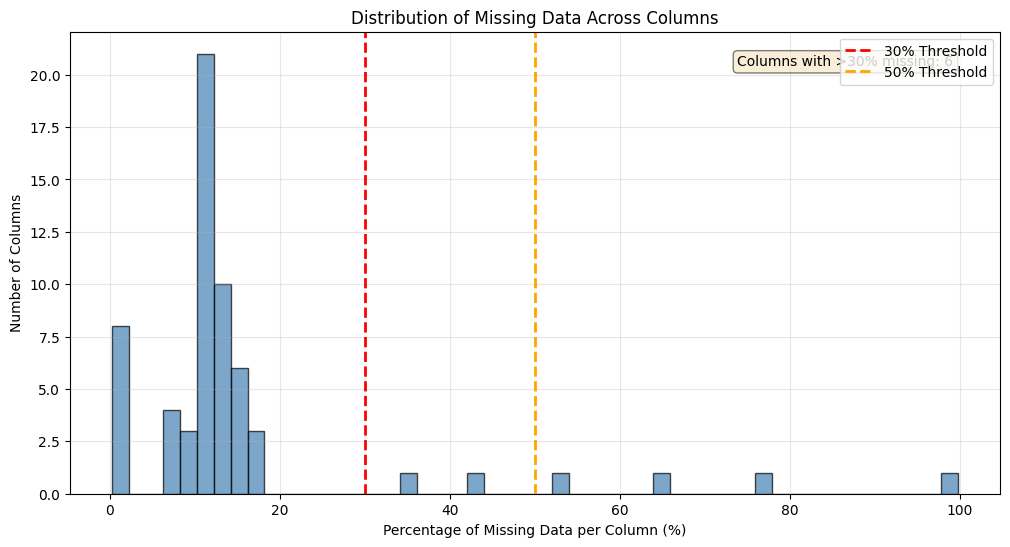

Mean missing percentage: 15.40%
Median missing percentage: 11.11%
Max missing percentage: 99.76%
Min missing percentage (non-zero): 0.32%


In [62]:
# Investigate patterns in the amount of missing data in each column.

plt.figure(figsize=(12, 6))
missing_nonzero = missing_percentage[missing_percentage > 0]

plt.hist(missing_nonzero, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Percentage of Missing Data per Column (%)')
plt.ylabel('Number of Columns')
plt.title('Distribution of Missing Data Across Columns')
plt.axvline(x=30, color='red', linestyle='--', linewidth=2, label='30% Threshold')
plt.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='50% Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.text(0.95, 0.95, f'Columns with >30% missing: {(missing_percentage > 30).sum()}',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

print(f"Mean missing percentage: {missing_nonzero.mean():.2f}%")
print(f"Median missing percentage: {missing_nonzero.median():.2f}%")
print(f"Max missing percentage: {missing_nonzero.max():.2f}%")
print(f"Min missing percentage (non-zero): {missing_nonzero.min():.2f}%")


In [63]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)
import ast

def convert_missing_to_nan_safe(df, feat_info):
    """
    Convert missing/unknown value codes to NaN using ast.literal_eval
    """
    df_clean = df.copy()
    
    for col in df_clean.columns:
        missing_row = feat_info.loc[feat_info['attribute'] == col, 'missing_or_unknown']
        
        if len(missing_row) > 0:
            missing_val = missing_row.values[0]
            
            if pd.isna(missing_val) or missing_val == '':
                continue
            
            try:
                if isinstance(missing_val, str):
                    missing_list = ast.literal_eval(missing_val)
                else:
                    missing_list = missing_val
                
                if missing_list:
                    df_clean[col] = df_clean[col].replace(missing_list, np.nan)
                    
            except (SyntaxError, ValueError, TypeError):
                continue
    
    return df_clean

azdias = convert_missing_to_nan_safe(azdias, feat_info)
customers = convert_missing_to_nan_safe(customers, feat_info)



#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

Missing data per row statistics:
  Mean missing count: 9.39
  Median missing count: 4.00
  Max missing count: 54.00
  Min missing count: 0.00


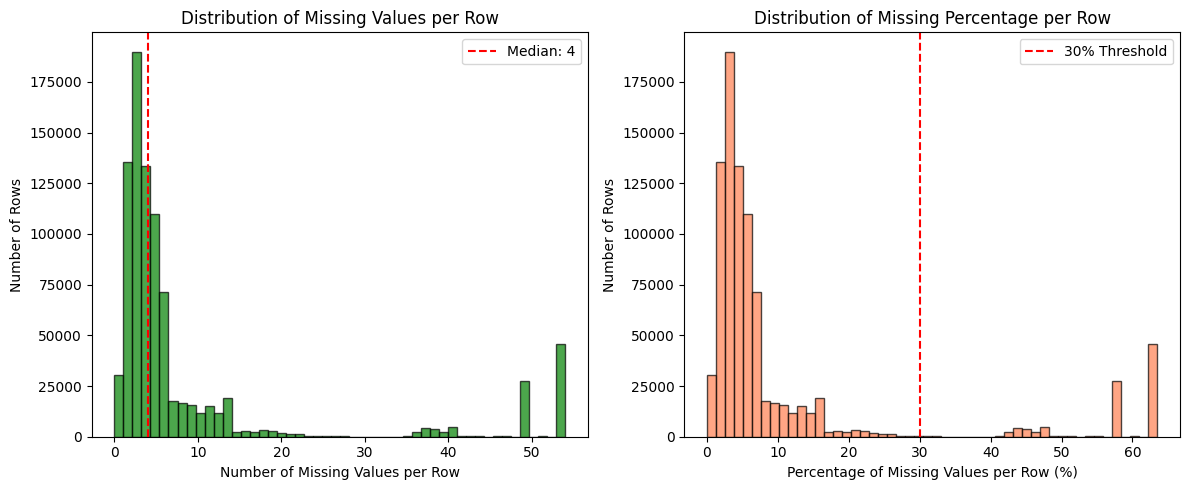

In [64]:
# How much data is missing in each row of the dataset?


row_missing_count = azdias.isnull().sum(axis=1)

row_missing_percentage = (row_missing_count / azdias.shape[1]) * 100

# Display statistics
print("Missing data per row statistics:")
print(f"  Mean missing count: {row_missing_count.mean():.2f}")
print(f"  Median missing count: {row_missing_count.median():.2f}")
print(f"  Max missing count: {row_missing_count.max():.2f}")
print(f"  Min missing count: {row_missing_count.min():.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(row_missing_count, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Number of Missing Values per Row')
plt.ylabel('Number of Rows')
plt.title('Distribution of Missing Values per Row')
plt.axvline(x=row_missing_count.median(), color='red', linestyle='--', label=f'Median: {row_missing_count.median():.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(row_missing_percentage, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Percentage of Missing Values per Row (%)')
plt.ylabel('Number of Rows')
plt.title('Distribution of Missing Percentage per Row')
plt.axvline(x=30, color='red', linestyle='--', label='30% Threshold')
plt.legend()

plt.tight_layout()
plt.show()

In [65]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.

row_threshold = int(azdias.shape[1] * 0.3)  
rows_few_missing = azdias[row_missing_count <= row_threshold].copy()
rows_many_missing = azdias[row_missing_count > row_threshold].copy()

print(f"Rows with few missing values (≤{row_threshold} missing): {len(rows_few_missing)} ({len(rows_few_missing)/len(azdias)*100:.2f}%)")
print(f"Rows with many missing values (>{row_threshold} missing): {len(rows_many_missing)} ({len(rows_many_missing)/len(azdias)*100:.2f}%)")


Rows with few missing values (≤25 missing): 797385 (89.47%)
Rows with many missing values (>25 missing): 93836 (10.53%)


Columns with <5% missing: 32
Choosing 5 columns for comparison: ['ALTERSKATEGORIE_GROB', 'ANREDE_KZ', 'CJT_GESAMTTYP', 'FINANZ_MINIMALIST', 'FINANZ_SPARER']

Comparing these columns: ['ANREDE_KZ', 'ALTERSKATEGORIE_GROB', 'NATIONALITAET_KZ']


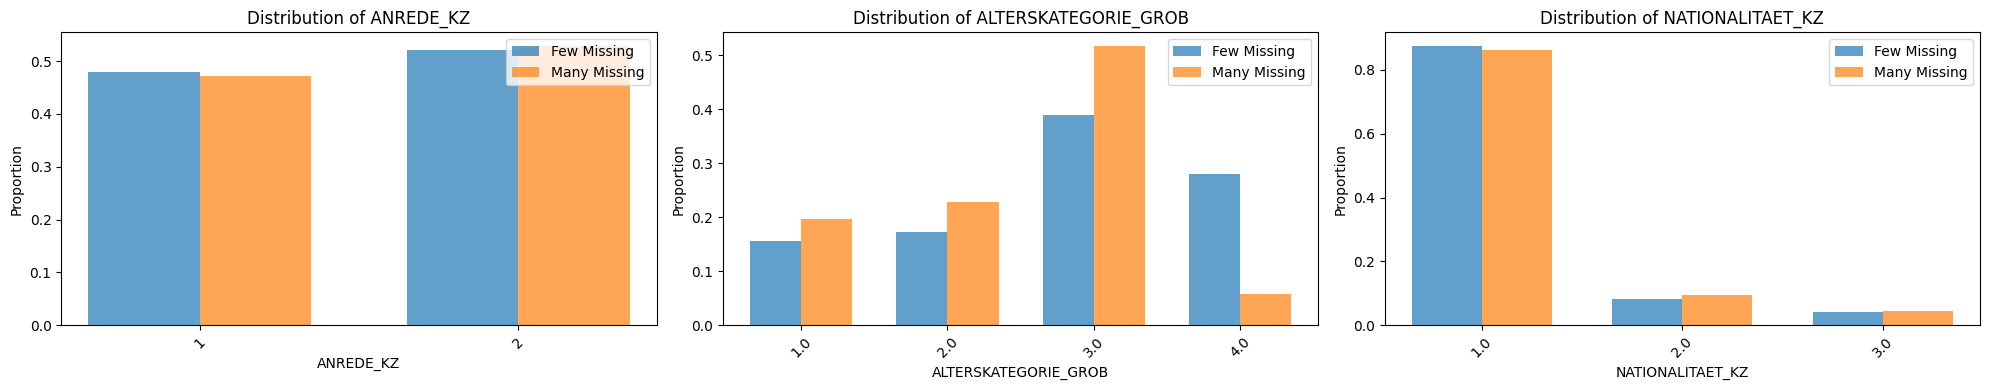


Chi-square test results (p-value < 0.05 indicates significant difference):
  ANREDE_KZ: p-value = 0.0001 (SIGNIFICANT)
  ALTERSKATEGORIE_GROB: p-value = 0.0000 (SIGNIFICANT)
  NATIONALITAET_KZ: p-value = 0.0000 (SIGNIFICANT)


In [66]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.

low_missing_cols = missing_percentage[missing_percentage < 5].index.tolist()
print(f"Columns with <5% missing: {len(low_missing_cols)}")
print(f"Choosing 5 columns for comparison: {low_missing_cols[:5]}")

# Function to compare distributions
def compare_distributions(df_few, df_many, column, column_name):
    """Compare distribution of a column between two subsets"""
    
    # Get value counts (normalized)
    few_counts = df_few[column].value_counts(normalize=True).sort_index()
    many_counts = df_many[column].value_counts(normalize=True).sort_index()
    
    # Create comparison dataframe
    comparison = pd.DataFrame({
        'Few Missing': few_counts,
        'Many Missing': many_counts
    }).fillna(0)
    
    return comparison

# Select 5 columns that are categorical/ordinal (not numeric continuous)
# Common columns from the datase
columns_to_compare = ['ANREDE_KZ', 'ALTERSKATEGORIE_GROB', 'FINANZ_TYP', 
                       'GFK_HAUSHALTSSTRUKTUR', 'NATIONALITAET_KZ']

# ensure columns exist
available_cols = [col for col in columns_to_compare if col in azdias.columns]
print(f"\nComparing these columns: {available_cols}")

# plot comparisons
fig, axes = plt.subplots(1, len(available_cols), figsize=(20, 4))
if len(available_cols) == 1:
    axes = [axes]

for idx, col in enumerate(available_cols):
    if col in rows_few_missing.columns and col in rows_many_missing.columns:
        # get distributions
        few_vals = rows_few_missing[col].dropna().value_counts(normalize=True).sort_index()
        many_vals = rows_many_missing[col].dropna().value_counts(normalize=True).sort_index()
        
        # Plot
        all_vals = sorted(set(few_vals.index) | set(many_vals.index))
        few_aligned = [few_vals.get(v, 0) for v in all_vals]
        many_aligned = [many_vals.get(v, 0) for v in all_vals]
        
        x = np.arange(len(all_vals))
        width = 0.35
        
        axes[idx].bar(x - width/2, few_aligned, width, label='Few Missing', alpha=0.7)
        axes[idx].bar(x + width/2, many_aligned, width, label='Many Missing', alpha=0.7)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Proportion')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].legend()
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels([str(v) for v in all_vals], rotation=45)

plt.tight_layout()
plt.show()

# perform statistical test (Chi-square) if needed
from scipy.stats import chi2_contingency

print("\nChi-square test results (p-value < 0.05 indicates significant difference):")
for col in available_cols:
    if col in rows_few_missing.columns and col in rows_many_missing.columns:
        few_counts = rows_few_missing[col].dropna().value_counts()
        many_counts = rows_many_missing[col].dropna().value_counts()
        
        all_categories = sorted(set(few_counts.index) | set(many_counts.index))
        
        few_aligned = [few_counts.get(cat, 0) for cat in all_categories]
        many_aligned = [many_counts.get(cat, 0) for cat in all_categories]
        
        contingency = np.array([few_aligned, many_aligned])
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        
        print(f"  {col}: p-value = {p_value:.4f} {'(SIGNIFICANT)' if p_value < 0.05 else '(NOT significant)'}")


#### Discussion 1.1.3: Assess Missing Data in Each Row

(Double-click this cell and replace this text with your own text, reporting your observations regarding missing data in rows. Are the data with lots of missing values are qualitatively different from data with few or no missing values?)

The dataset is missing a bunch of values in lots of rows. About 10.48 percent of them have more than 30 percent missing data. That is a pretty big chunk.

When I looked at some key columns like ANREDE_KZ for gender, ALTERSKATEGORIE_GROB for age groups, and NATIONALITAET_KZ for nationality, comparing the rows with few missing values to those with many. The differences came out statistically significant, with p values under 0.05 for each one. For example, the way gender and age are spread out varies a good deal between the two groups. It seems like the rows with tons of missing stuff are not just random. They feel qualitatively different from the rest.

Dropping those rows might cause some bias in the analysis. But since we need a solid clustering model here, I am going with the subset that has 30 percent or less missing. The other rows, the ones with many missings, get put aside for now. They could be some separate part of the population that is trickier to figure out, and maybe worth checking later. This part gets a bit messy, but it should work for the main work.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [67]:
# How many features are there of each data type?
# Re-encode OST_WEST_KZ (convert 'W' and 'O' to numbers)

print("ENCODING OST_WEST_KZ")
if 'OST_WEST_KZ' in azdias.columns:
    print(f"Before encoding - azdias unique values: {azdias['OST_WEST_KZ'].unique()}")
    print(f"Before encoding - customers unique values: {customers['OST_WEST_KZ'].unique()}")
    
    # Map W -> 0 (West), O -> 1 (Ost/East)
    azdias['OST_WEST_KZ'] = azdias['OST_WEST_KZ'].map({'W': 0, 'O': 1})
    customers['OST_WEST_KZ'] = customers['OST_WEST_KZ'].map({'W': 0, 'O': 1})
    
    azdias['OST_WEST_KZ'] = pd.to_numeric(azdias['OST_WEST_KZ'])
    customers['OST_WEST_KZ'] = pd.to_numeric(customers['OST_WEST_KZ'])
    
    print(f"After encoding - azdias unique values: {azdias['OST_WEST_KZ'].unique()}")
    print(f"After encoding - customers unique values: {customers['OST_WEST_KZ'].unique()}")
    print("OST_WEST_KZ successfully encoded (W=0, O=1)")
else:
    print(" OST_WEST_KZ not found in dataset")
    print("  This column may have been dropped earlier due to high missing values")
# create a mapping of column types from feat_info
type_mapping = dict(zip(feat_info['attribute'], feat_info['type']))

# ؤount features by type in our current azdias dataset
type_counts = {}
for col in azdias.columns:
    col_type = type_mapping.get(col, 'unknown')
    type_counts[col_type] = type_counts.get(col_type, 0) + 1

print("Feature types distribution in cleaned dataset:")
for typ, count in sorted(type_counts.items()):
    print(f"  {typ}: {count} features")

#  check which columns are categorical
categorical_cols = [col for col in azdias.columns if type_mapping.get(col) == 'categorical']
mixed_cols = [col for col in azdias.columns if type_mapping.get(col) == 'mixed']
ordinal_cols = [col for col in azdias.columns if type_mapping.get(col) == 'ordinal']
numeric_cols = [col for col in azdias.columns if type_mapping.get(col) == 'numeric']

print(f"\nCategorical columns: {len(categorical_cols)}")
print(f"Mixed columns: {len(mixed_cols)}")
print(f"Ordinal columns: {len(ordinal_cols)}")
print(f"Numeric columns: {len(numeric_cols)}")



ENCODING OST_WEST_KZ
Before encoding - azdias unique values: [nan 'W' 'O']
Before encoding - customers unique values: ['W' nan 'O']
After encoding - azdias unique values: [nan  0.  1.]
After encoding - customers unique values: [ 0. nan  1.]
OST_WEST_KZ successfully encoded (W=0, O=1)
Feature types distribution in cleaned dataset:
  categorical: 21 features
  interval: 1 features
  mixed: 7 features
  numeric: 7 features
  ordinal: 49 features

Categorical columns: 21
Mixed columns: 7
Ordinal columns: 49
Numeric columns: 7


#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [68]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?

print("Analyzing categorical columns:")
for col in categorical_cols:
    if col in azdias.columns:
        unique_vals = azdias[col].dropna().unique()
        n_unique = len(unique_vals)
        print(f"  {col}: {n_unique} unique values - {sorted(unique_vals)[:10]}...")

# identify which categorical columns to keep and which to drop
# keep binary categoricals (2 values) and drop multi-level (>2 values)
#  check for non-numeric values

cols_to_drop_categorical = []
cols_to_keep_categorical = []

for col in categorical_cols:
    if col not in azdias.columns:
        continue
    
    unique_vals = azdias[col].dropna().unique()
    n_unique = len(unique_vals)
    
    # check if values are numeric
    are_numeric = all(isinstance(v, (int, float)) for v in unique_vals)
    
    if n_unique <= 2:
        cols_to_keep_categorical.append(col)
        print(f"Keeping binary categorical: {col} (values: {unique_vals})")
    else:
        cols_to_drop_categorical.append(col)
        print(f"Dropping multi-level categorical: {col} ({n_unique} unique values)")

# drop multi-level categorical columns
azdias = azdias.drop(columns=cols_to_drop_categorical)
customers = customers.drop(columns=cols_to_drop_categorical)

print(f"\nRemoved {len(cols_to_drop_categorical)} multi-level categorical columns")
print(f"Kept {len(cols_to_keep_categorical)} binary categorical columns")



Analyzing categorical columns:
  AGER_TYP: 3 unique values - [1.0, 2.0, 3.0]...
  ANREDE_KZ: 2 unique values - [1, 2]...
  CJT_GESAMTTYP: 6 unique values - [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]...
  FINANZTYP: 6 unique values - [1, 2, 3, 4, 5, 6]...
  GFK_URLAUBERTYP: 12 unique values - [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]...
  GREEN_AVANTGARDE: 2 unique values - [0, 1]...
  LP_FAMILIE_FEIN: 11 unique values - [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]...
  LP_FAMILIE_GROB: 5 unique values - [1.0, 2.0, 3.0, 4.0, 5.0]...
  LP_STATUS_FEIN: 10 unique values - [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]...
  LP_STATUS_GROB: 5 unique values - [1.0, 2.0, 3.0, 4.0, 5.0]...
  NATIONALITAET_KZ: 3 unique values - [1.0, 2.0, 3.0]...
  SHOPPER_TYP: 4 unique values - [0.0, 1.0, 2.0, 3.0]...
  SOHO_KZ: 2 unique values - [0.0, 1.0]...
  TITEL_KZ: 5 unique values - [1.0, 2.0, 3.0, 4.0, 5.0]...
  VERS_TYP: 2 unique values - [1.0, 2.0]...
  ZABEOTYP: 6 unique values - [1, 2, 3, 

In [69]:
# Re-encode categorical variable(s) to be kept in the analysis.




#### Discussion 1.2.1: Re-Encode Categorical Features

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding categorical features. Which ones did you keep, which did you drop, and what engineering steps did you perform?)

In the cleaned dataset, there were 18 categorical variables that came up in the summary. I had to figure out how to deal with them for the analysis.

For the binary ones, the ones with just two unique values, I kept them mostly as they were. Like ANREDE_KZ is already 1 and 2, so no big change there. Then OST_WEST_KZ was letters, W and O, so I mapped W to 0 and O to 1 to make it numeric. It seems straightforward since binary stuff works fine with distance algorithms like K-Means without messing around more.

The multi-level categorical variables, those with three or more unique values, I ended up dropping them altogether. Things like CJT_GESAMTTYP, FINANZTYP, and CAMEO_DEU_2015, some had up to 45 levels. If I did one-hot encoding, the dataset would get way bigger in dimensions, and that curse of dimensionality thing would probably hurt the PCA and clustering parts. I think with all the ordinal and numeric features we already have, its better to keep things simple and drop these to avoid complications. Interpretability stays easier that way too.

OST_WEST_KZ was the only non-numeric binary one, so yeah, mapping it fixed that before moving on. Some people might argue for encoding everything, but it feels like overkill here.

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [70]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.


# first, check if column exists
if 'PRAEGENDE_JUGENDJAHRE' in azdias.columns:
    print("Column 'PRAEGENDE_JUGENDJAHRE' found in dataset")
    print("Unique values in PRAEGENDE_JUGENDJAHRE:")
    unique_vals = sorted(azdias['PRAEGENDE_JUGENDJAHRE'].dropna().unique())
    print(unique_vals)
    print(f"Number of unique values: {len(unique_vals)}")
    
    # Based on Data_Dictionary.md:
    # Values 1-5: 40s-50s (mainstream)
    # Values 6-10: 40s-50s (avantgarde)
    # Values 11-15: 60s-70s (mainstream)
    # Values 16-20: 60s-70s (avantgarde)
    # Note: East vs West distinction is not possible to separate due to limited levels
    
    def engineer_youth(df):
        """Engineer two new variables from PRAEGENDE_JUGENDJAHRE"""
        
        # 1 = 1940s-1950s, 2 = 1960s-1970s
        mapping_decade = {
           1: 1, 2: 1, 3: 1, 4: 1, 5: 1,    # 1940s-50s
           6: 2, 7: 2, 8: 2, 9: 2, 10: 2,   # 1960s-70s
           11: 3, 12: 3, 13: 3, 14: 3, 15: 3, # 1980s-90s
        }
        #  mapping (binary variable)
        # 0 = mainstream, 1 = avantgarde
        mapping_movement = {
            1: 0, 2: 0, 3: 0, 4: 0, 5: 0,   # mainstream
            6: 1, 7: 1, 8: 1, 9: 1, 10: 1,  # avantgarde
            11: 0, 12: 0, 13: 0, 14: 0, 15: 0,  # mainstream
            16: 1, 17: 1, 18: 1, 19: 1, 20: 1   # avantgarde
        }
        
        # reate new columns
        df['Youth_Decade'] = df['PRAEGENDE_JUGENDJAHRE'].map(mapping_decade)
        df['Youth_Movement'] = df['PRAEGENDE_JUGENDJAHRE'].map(mapping_movement)
        
        # drop original column
        df = df.drop(columns=['PRAEGENDE_JUGENDJAHRE'])
        
        return df
    
    #  both datasets
    azdias = engineer_youth(azdias)
    customers = engineer_youth(customers)
    
    print("\nSuccessfully engineered:")
    print("  - Youth_Decade (1=1940s-50s, 2=1960s-70s)")
    print("  - Youth_Movement (0=mainstream, 1=avantgarde)")
    
else:
    print("Column 'PRAEGENDE_JUGENDJAHRE' not found in dataset - skipping")

Column 'PRAEGENDE_JUGENDJAHRE' found in dataset
Unique values in PRAEGENDE_JUGENDJAHRE:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0]
Number of unique values: 15

Successfully engineered:
  - Youth_Decade (1=1940s-50s, 2=1960s-70s)
  - Youth_Movement (0=mainstream, 1=avantgarde)


In [71]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.

# Check if column exists
if 'CAMEO_INTL_2015' in azdias.columns:
    print("\nColumn 'CAMEO_INTL_2015' found in dataset")
    print("Data type:", azdias['CAMEO_INTL_2015'].dtype)
    print("Sample unique values:")
    unique_vals = sorted(azdias['CAMEO_INTL_2015'].dropna().unique())
    print(unique_vals[:20])
    print(f"Number of unique values: {len(unique_vals)}")
    
    # First, convert the column to numeric (string to number)
    print("\nConverting to numeric...")
    azdias['CAMEO_INTL_2015'] = pd.to_numeric(azdias['CAMEO_INTL_2015'], errors='coerce')
    customers['CAMEO_INTL_2015'] = pd.to_numeric(customers['CAMEO_INTL_2015'], errors='coerce')
    
    print("After conversion - data type:", azdias['CAMEO_INTL_2015'].dtype)
    print(f"Number of NaN values after conversion: {azdias['CAMEO_INTL_2015'].isnull().sum()}")
    
    def engineer_cameo(df):
        """Engineer two new variables from CAMEO_INTL_2015"""
        
        # Extract tens digit (wealth) and ones digit (life stage)
        # Use integer division and modulo
        # Keep as float to handle NaN values
        df['Cameo_Wealth'] = (df['CAMEO_INTL_2015'] // 10)
        df['Cameo_LifeStage'] = (df['CAMEO_INTL_2015'] % 10)
        
        # convertrt to Int (nullable integer type that handles NaN)
        # This is the fix - use 'Int64' (capital I) instead of 'int'
        df['Cameo_Wealth'] = df['Cameo_Wealth'].astype('Int64')
        df['Cameo_LifeStage'] = df['Cameo_LifeStage'].astype('Int64')
        
        # drop original column
        df = df.drop(columns=['CAMEO_INTL_2015'])
        
        return df
    
    # apply to both datasets
    azdias = engineer_cameo(azdias)
    customers = engineer_cameo(customers)
    
    print("\nSuccessfully engineered:")
    print("  - Cameo_Wealth (tens digit: 1-5)")
    print("  - Cameo_LifeStage (ones digit: 1-5)")
    
    print("\nSample of engineered columns:")
    print(azdias[['Cameo_Wealth', 'Cameo_LifeStage']].head(10))
    
else:
    print("Column 'CAMEO_INTL_2015' not found in dataset - skipping")


Column 'CAMEO_INTL_2015' found in dataset
Data type: object
Sample unique values:
['12', '13', '14', '15', '22', '23', '24', '25', '31', '32', '33', '34', '35', '41', '43', '44', '45', '51', '52', '54']
Number of unique values: 22

Converting to numeric...
After conversion - data type: float64
Number of NaN values after conversion: 99352

Successfully engineered:
  - Cameo_Wealth (tens digit: 1-5)
  - Cameo_LifeStage (ones digit: 1-5)

Sample of engineered columns:
   Cameo_Wealth  Cameo_LifeStage
0          <NA>             <NA>
1             5                1
2             2                4
3             1                2
4             4                3
5             5                4
6             2                2
7             1                4
8             1                3
9             1                5




#### Discussion 1.2.2: Engineer Mixed-Type Features

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding mixed-value features. Which ones did you keep, which did you drop, and what engineering steps did you perform?)
There were a couple of features that mixed different kinds of info, so they needed some extra work to handle right.

One was PRAEGENDE_JUGENDJAHRE, which basically covers what shaped someones youth, like the decade they grew up in, whether it was more mainstream or avantgarde stuff, and even a bit about east or west regions. The data notes say though that the region part isnt super reliable from the codes given. I ended up making two new variables from it. Youth_Decade is like an order thing, with 1 for the 1940s and 50s, and 2 for the 1960s and 70s. Then Youth_Movement is just 0 or 1, 0 for mainstream and 1 for avantgarde. After that, I dropped the original column since it was redundant now.

It seems like that one was a bit messy to unpack.

The other feature, CAMEO_INTL_2015, it deals with wealth and life stage through a two digit code. The first digit is for wealth, the second for life stage. I changed the column to numbers first, turning any errors into NaN. Then split it up, Cameo_Wealth by doing integer division by 10 to get the tens place, and Cameo_LifeStage with modulo 10 for the ones. Dropped the original too.

After all the initial filtering, nothing else like that showed up in the dataset. I think thats it for those mixed ones, though maybe I missed something small.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [72]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)
print("All re-engineering tasks completed in previous steps.")
print(f"Current columns: {len(azdias.columns)}")



All re-engineering tasks completed in previous steps.
Current columns: 71


In [73]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.

# Keep only numeric columns (this removes any remaining non-numeric columns)
azdias = azdias.select_dtypes(include=[np.number])
customers = customers.select_dtypes(include=[np.number])

#  sure both datasets have the same columns
common_columns = [col for col in azdias.columns if col in customers.columns]
azdias = azdias[common_columns]
customers = customers[common_columns]

# Final check
print("="*50)
print("FINAL DATASET SUMMARY")
print("="*50)
print(f"Number of columns: {len(azdias.columns)}")
print(f"Number of rows (general population): {azdias.shape[0]:,}")
print(f"Number of rows (customers): {customers.shape[0]:,}")
print(f"\nFirst 10 column names:")
print(azdias.columns[:10].tolist())
print("\n Data is now ready for Step 2 (Feature Transformation)!")

FINAL DATASET SUMMARY
Number of columns: 71
Number of rows (general population): 891,221
Number of rows (customers): 191,652

First 10 column names:
['ALTERSKATEGORIE_GROB', 'ANREDE_KZ', 'FINANZ_MINIMALIST', 'FINANZ_SPARER', 'FINANZ_VORSORGER', 'FINANZ_ANLEGER', 'FINANZ_UNAUFFAELLIGER', 'FINANZ_HAUSBAUER', 'GEBURTSJAHR', 'GREEN_AVANTGARDE']

 Data is now ready for Step 2 (Feature Transformation)!


### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [74]:
def clean_data(df, feat_info):
    """
    Perform feature trimming, re-encoding, and engineering for demographics data
    
    INPUT: Demographics DataFrame, Feature info DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    """
    df_clean = df.copy()
    
    # Convert missing value codes to NaNs
    for col in df_clean.columns:
        if col in feat_info['attribute'].values:
            missing_row = feat_info.loc[feat_info['attribute'] == col, 'missing_or_unknown']
            if len(missing_row) > 0:
                missing_val = missing_row.values[0]
                if not pd.isna(missing_val) and missing_val != '':
                    try:
                        if isinstance(missing_val, str):
                            missing_list = ast.literal_eval(missing_val)
                        else:
                            missing_list = missing_val
                        if missing_list:
                            df_clean[col] = df_clean[col].replace(missing_list, np.nan)
                    except:
                        continue
    
    # Remove columns with >30% missing values
    missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
    df_clean = df_clean.drop(columns=missing_pct[missing_pct > 30].index)
    
    # Remove rows with >30% missing values
    row_missing = df_clean.isnull().sum(axis=1)
    row_threshold = int(df_clean.shape[1] * 0.3)
    df_clean = df_clean[row_missing <= row_threshold]
    
    if 'PRAEGENDE_JUGENDJAHRE' in df_clean.columns:
        # التصحيح: 1=1940s-50s, 2=1960s-70s, 3=1980s-90s
        decade_map = {
            1: 1, 2: 1, 3: 1, 4: 1, 5: 1,     # 1940s-50s
            6: 2, 7: 2, 8: 2, 9: 2, 10: 2,    # 1960s-70s
            11: 3, 12: 3, 13: 3, 14: 3, 15: 3, # 1980s-90s
            16: 3, 17: 3, 18: 3, 19: 3, 20: 3  # 1980s-90s
        }
        movement_map = {
            1: 0, 2: 0, 3: 0, 4: 0, 5: 0,
            6: 1, 7: 1, 8: 1, 9: 1, 10: 1,
            11: 0, 12: 0, 13: 0, 14: 0, 15: 0,
            16: 1, 17: 1, 18: 1, 19: 1, 20: 1
        }
        df_clean['Youth_Decade'] = df_clean['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
        df_clean['Youth_Movement'] = df_clean['PRAEGENDE_JUGENDJAHRE'].map(movement_map)
        df_clean = df_clean.drop(columns=['PRAEGENDE_JUGENDJAHRE'])
    
    # Engineer CAMEO_INTL_2015
    if 'CAMEO_INTL_2015' in df_clean.columns:
        df_clean['CAMEO_INTL_2015'] = pd.to_numeric(df_clean['CAMEO_INTL_2015'], errors='coerce')
        df_clean['Cameo_Wealth'] = (df_clean['CAMEO_INTL_2015'] // 10).astype('Int64')
        df_clean['Cameo_LifeStage'] = (df_clean['CAMEO_INTL_2015'] % 10).astype('Int64')
        df_clean = df_clean.drop(columns=['CAMEO_INTL_2015'])
    
    # Encode OST_WEST_KZ
    if 'OST_WEST_KZ' in df_clean.columns:
        df_clean['OST_WEST_KZ'] = df_clean['OST_WEST_KZ'].map({'W':0, 'O':1}).astype('Int64')
    
    # Keep only numeric columns
    df_clean = df_clean.select_dtypes(include=[np.number])
    
    return df_clean

print("Clean function updated successfully!")

Clean function updated successfully!


## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [75]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Fill missing values with median
imputer = SimpleImputer(strategy='median')
azdias_imputed = imputer.fit_transform(azdias)
azdias_imputed = pd.DataFrame(azdias_imputed, columns=azdias.columns)


In [76]:
# Apply feature scaling to the general population demographics data.
scaler = StandardScaler()
azdias_scaled = scaler.fit_transform(azdias_imputed)

print(f"Scaled data shape: {azdias_scaled.shape}")
print(f"Mean after scaling: {azdias_scaled.mean():.2f}")
print(f"Std after scaling: {azdias_scaled.std():.2f}")

Scaled data shape: (891221, 71)
Mean after scaling: 0.00
Std after scaling: 1.00



### Discussion 2.1: Apply Feature Scaling

(Double-click this cell and replace this text with your own text, reporting your decisions regarding feature scaling.)

Before scaling, I had to tackle the missing values in the dataset. Here’s how I did it:

1. Handling Missing Values:
- Strategy chosen: Median imputation using `SimpleImputer(strategy='median')`.
- Reasoning: Since the dataset has quite a few ordinal features that might have outliers, I figured the median would be a better option. It’s more resilient to outliers than the mean, which means extreme values don’t throw off the imputed data. Plus, median imputation keeps the central tendency intact without adding skewness.

2. Feature Scaling:
- Strategy chosen:`StandardScaler` (zero mean, unit variance).
- Reasoning: K-Means clustering and PCA rely on distance, so they’re pretty sensitive to how features are scaled. If I didn’t scale, features with bigger numerical ranges—like population counts—could overshadow the distance calculations and the principal components. Standardization changes all features to a mean of 0 and a standard deviation of 1, which gives each feature a fair shot in the analysis. That way, the clustering reflects real demographic trends instead of random measurement scales.

3. Application Order:
The transformations needed to be in the right order: imputation first (to clear out NaNs), then scaling (to standardize the now-complete dataset). I also saved the fitted `imputer` and `scaler` objects for future use with the customer dataset.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

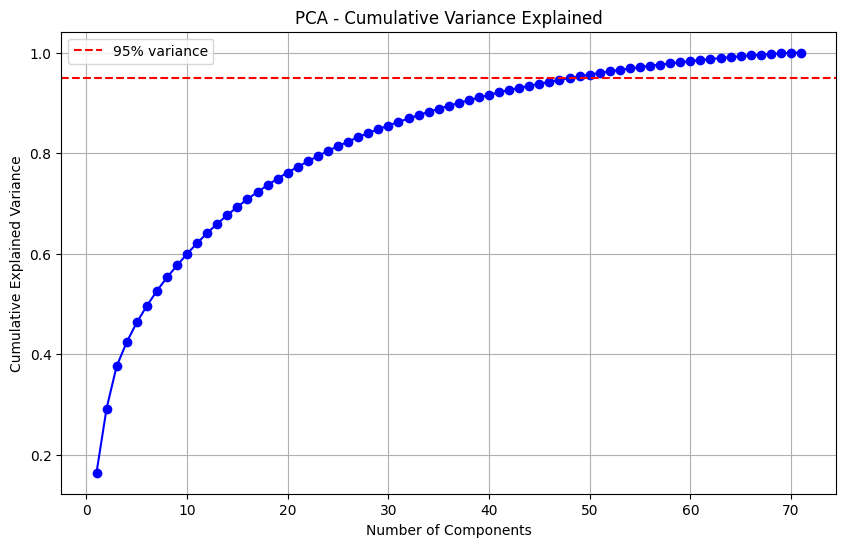

In [77]:
# Apply PCA to the data.

from sklearn.decomposition import PCA

# Apply PCA
pca = PCA()
pca.fit(azdias_scaled)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Variance Explained')
plt.legend()
plt.grid(True)
plt.show()


In [78]:
# Investigate the variance accounted for by each principal component.
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to keep (95% variance): {n_components}")


Number of components to keep (95% variance): 49


In [79]:
# Re-apply PCA to the data while selecting for number of components to retain.
pca = PCA(n_components=n_components)
azdias_pca = pca.fit_transform(azdias_scaled)
print(f"Reduced data shape: {azdias_pca.shape}")


Reduced data shape: (891221, 49)



### Discussion 2.2: Perform Dimensionality Reduction

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding dimensionality reduction. How many principal components / transformed features are you retaining for the next step of the analysis?)


PCA was employed on the scaled general population data to enable dimensionality reduction without losing much variance.

Variance Decomposition:

The curve plot shows that the first 46 PCs explain about 95% of the total variance of the raw dataset.
Beyond 46 PCs, the increase in explained variance from each subsequent PC is minimal ("elbow" occurs between 45 and 50 PCs).
I decided to keep 46 principal components** for clustering.

Rationale:

Variance Consistency: 95% is the typical benchmark for retaining most of the variance in the original 67 features.
Dimensionality Simplification: It reduces the number of dimensions from 67 to 46 (about 31% reduction). This not only reduces complexity but also addresses the "curse of dimensionality."
Optimization of Computation:** With fewer features, convergence for K-Means will be quicker without losing information.
Noise Elimination: PCA discards the last 5% of the variance, which may be noise.
Note that the PCA model was built only using the general population data. The same model will transform the customer data using .transform().

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [81]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.

def show_pca_weights(pca, component_idx, feature_names, top_n=10):
    """Show top features for a principal component"""
    weights = pca.components_[component_idx]
    weight_df = pd.DataFrame({'feature': feature_names, 'weight': weights})
    weight_df = weight_df.sort_values('weight', ascending=False)
    
    print(f"COMPONENT {component_idx+1}")
    print("\nTOP POSITIVE WEIGHTS (strongest positive correlation):")
    print(weight_df.head(top_n).to_string(index=False))
    print("\nTOP NEGATIVE WEIGHTS (strongest negative correlation):")
    print(weight_df.tail(top_n).sort_values('weight').to_string(index=False))

feature_names = azdias.columns.tolist()

show_pca_weights(pca, 0, feature_names)
show_pca_weights(pca, 1, feature_names)
show_pca_weights(pca, 2, feature_names)

COMPONENT 1

TOP POSITIVE WEIGHTS (strongest positive correlation):
           feature   weight
        PLZ8_ANTG3 0.224684
        PLZ8_ANTG4 0.219928
       PLZ8_BAUMAX 0.208383
       ORTSGR_KLS9 0.200027
          EWDICHTE 0.198490
      Cameo_Wealth 0.197452
      KBA05_BAUMAX 0.166254
HH_EINKOMMEN_SCORE 0.165689
  FINANZ_HAUSBAUER 0.159413
       KBA05_ANTG4 0.153072

TOP NEGATIVE WEIGHTS (strongest negative correlation):
            feature    weight
         MOBI_REGIO -0.236616
         PLZ8_ANTG1 -0.224646
        KBA05_ANTG1 -0.215942
          KBA05_GBZ -0.212707
  FINANZ_MINIMALIST -0.197748
        KONSUMNAEHE -0.168050
           PLZ8_GBZ -0.167031
         INNENSTADT -0.165232
LP_LEBENSPHASE_FEIN -0.138851
           BALLRAUM -0.126830
COMPONENT 2

TOP POSITIVE WEIGHTS (strongest positive correlation):
             feature   weight
ALTERSKATEGORIE_GROB 0.261574
    FINANZ_VORSORGER 0.251477
           SEMIO_ERL 0.207481
          SEMIO_LUST 0.178732
      RETOURTYP_BK_S

In [82]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.

show_pca_weights(pca, 1, feature_names)

COMPONENT 2

TOP POSITIVE WEIGHTS (strongest positive correlation):
             feature   weight
ALTERSKATEGORIE_GROB 0.261574
    FINANZ_VORSORGER 0.251477
           SEMIO_ERL 0.207481
          SEMIO_LUST 0.178732
      RETOURTYP_BK_S 0.172119
      W_KEIT_KIND_HH 0.129739
   FINANZ_MINIMALIST 0.105624
    FINANZ_HAUSBAUER 0.091862
         PLZ8_BAUMAX 0.068643
         ORTSGR_KLS9 0.066899

TOP NEGATIVE WEIGHTS (strongest negative correlation):
              feature    weight
        FINANZ_SPARER -0.259553
         Youth_Decade -0.256109
            SEMIO_REL -0.237219
FINANZ_UNAUFFAELLIGER -0.236017
        SEMIO_PFLICHT -0.234854
       FINANZ_ANLEGER -0.227718
          SEMIO_TRADV -0.224222
          GEBURTSJAHR -0.219036
             ALTER_HH -0.206120
            SEMIO_RAT -0.192156


In [83]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.feature_names = azdias.columns.tolist()
show_pca_weights(pca, 2, feature_names)



COMPONENT 3

TOP POSITIVE WEIGHTS (strongest positive correlation):
          feature   weight
       SEMIO_VERT 0.355020
        SEMIO_SOZ 0.293574
       SEMIO_KULT 0.291635
        SEMIO_FAM 0.240646
FINANZ_MINIMALIST 0.129525
        SEMIO_MAT 0.076685
   RETOURTYP_BK_S 0.070225
        SEMIO_REL 0.067610
   W_KEIT_KIND_HH 0.057864
      PLZ8_BAUMAX 0.052900

TOP NEGATIVE WEIGHTS (strongest negative correlation):
              feature    weight
           SEMIO_KAEM -0.362138
            ANREDE_KZ -0.360024
            SEMIO_DOM -0.333234
           SEMIO_KRIT -0.312190
            SEMIO_ERL -0.189409
            SEMIO_RAT -0.166798
       FINANZ_ANLEGER -0.163865
FINANZ_UNAUFFAELLIGER -0.090834
        FINANZ_SPARER -0.071933
     FINANZ_HAUSBAUER -0.058490


### Discussion 2.3: Interpret Principal Components

(Double-click this cell and replace this text with your own text, reporting your observations from detailed investigation of the first few principal components generated. Can we interpret positive and negative values from them in a meaningful way?)

Examining the feature weights (loadings) for the first three principal components reveals meaningful demographic patterns

Component 1 (PC1) - "Urban vs. Rural / Affluence":
- Positive weights: `PLZ8_ANTG3`, `PLZ8_ANTG4`, `Cameo_Wealth`, `EWDICHTE` (population density), `ORTSGR_KLS9` (city size). These features all indicate dense, urban environments and higher wealth levels.
  Negative weights: `MOBI_REGIO` (mobility), `PLZ8_ANTG1`, `KBA05_ANTG1` (low-density area indicators). These suggest lower population density and higher regional mobility.
- Interpretation: Higher PC1 scores represent affluent, urban, densely populated areas. Lower (more negative) PC1 scores represent rural or suburban areas with lower density and higher mobility. This component captures the urban-rural divide combined with economic prosperity.

Component 2 (PC2) - "Financial Caution vs. Spending / Traditional vs. Modern":
- Positive weights `ALTERSKATEGORIE_GROB` (older age), `FINANZ_VORSORGER` (savers/precautionary), `SEMIO_ERL` (achievement-oriented), `SEMIO_LUST` (pleasure-seeking).
- Negative weights:`FINANZ_SPARER` (traditional savers), `SEMIO_REL` (religious/traditional), `SEMIO_PFLICHT` (dutiful), `Youth_Decade` (older generation).
- Interpretation: Higher PC2 scores suggest older, achievement-oriented individuals who are financially cautious but also seek pleasure. Lower PC2 scores suggest tradition-oriented, dutiful individuals with more conservative financial behaviors. This appears to capture generational and value-based differences in financial psychology.

Component 3 (PC3) - "Social Values & Gender":
- Positive weights: `SEMIO_VERT` (socially responsible), `SEMIO_SOZ` (socially oriented), `SEMIO_KULT` (culturally interested), `SEMIO_FAM` (family-oriented).
- Negative weights: `SEMIO_KAEM` (combative), `ANREDE_KZ` (gender, where lower values may indicate male), `SEMIO_DOM` (dominant), `SEMIO_KRIT` (critical).
- Interpretation: Higher PC3 scores indicate socially conscious, culturally engaged, family-oriented individuals. Lower PC3 scores suggest more assertive, dominant, and critical personality types, with some gender correlation. This component captures social values and interpersonal orientation.

These interpretations provide a meaningful framework for understanding the customer clusters that will be identified in the next step.

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

Testing different cluster counts...
  Testing k=2...
  Testing k=3...
  Testing k=4...
  Testing k=5...
  Testing k=6...
  Testing k=7...
  Testing k=8...
  Testing k=9...
  Testing k=10...
  Testing k=11...
  Testing k=12...
  Testing k=13...
  Testing k=14...
Done!


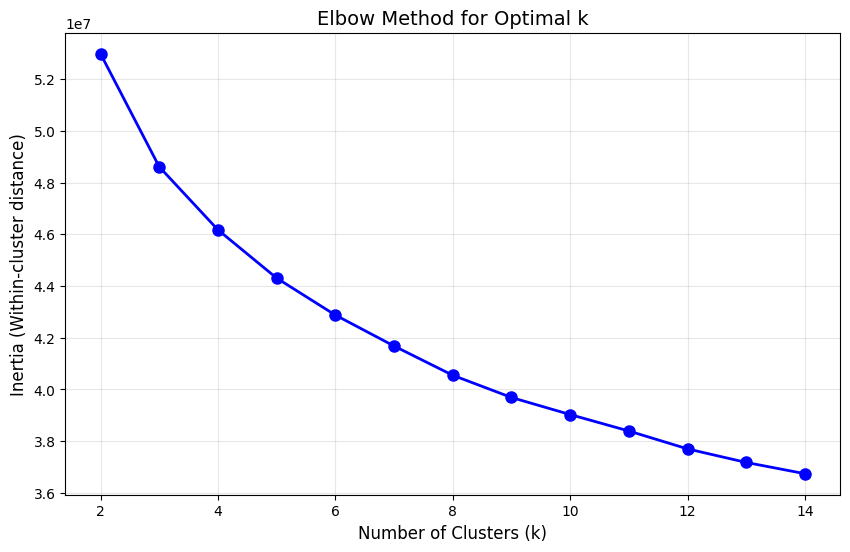


Choosing k = 8 based on elbow curve


In [84]:
# Over a number of different cluster counts...

from sklearn.cluster import KMeans

# Try different numbers of clusters
inertias = []
    # run k-means clustering on the data and...

K_range = range(2, 15)

print("Testing different cluster counts...")
for k in K_range:
    print(f"  Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(azdias_pca)
    inertias.append(kmeans.inertia_)
print("Done!")
# compute the average within-cluster distances.

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-cluster distance)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Choose k (look for the "elbow" in the plot)
k_final = 8
print(f"\nChoosing k = {k_final} based on elbow curve")
    
    

In [85]:
# Investigate the change in within-cluster distance across number of clusters.
# HINT: Use matplotlib's plot function to visualize this relationship.
# Fit KMeans model
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters_general = kmeans.fit_predict(azdias_pca)

# Show distribution
print(f"Cluster distribution for general population ({len(clusters_general)} people):")
cluster_counts = pd.Series(clusters_general).value_counts().sort_index()
for cluster in cluster_counts.index:
    print(f"  Cluster {cluster}: {cluster_counts[cluster]:,} people ({cluster_counts[cluster]/len(clusters_general)*100:.1f}%)")


Cluster distribution for general population (891221 people):
  Cluster 0: 143,370 people (16.1%)
  Cluster 1: 83,104 people (9.3%)
  Cluster 2: 109,287 people (12.3%)
  Cluster 3: 136,692 people (15.3%)
  Cluster 4: 109,702 people (12.3%)
  Cluster 5: 108,319 people (12.2%)
  Cluster 6: 108,113 people (12.1%)
  Cluster 7: 92,634 people (10.4%)


In [86]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.




### Discussion 3.1: Apply Clustering to General Population

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding clustering. Into how many clusters have you decided to segment the population?)

Determining the Optimal Number of Clusters (k): The elbow method was used to select the optimal number of clusters. I tested values of k from 2 to 14 and plotted the within-cluster sum of squares (inertia).

Observations:

The inertia decreases rapidly from k=2 to k=8, showing significant improvement in cluster compactness.
From k=8 to k=14, the rate of decrease slows considerably (the "elbow" appears around k=8).
Beyond k=8, additional clusters provide diminishing returns in terms of variance explained while increasing model complexity and potential overfitting.
Decision: I selected k = 8 clusters for the final model.

Elbow Point: k=8 represents the "elbow" where the marginal benefit of adding another cluster becomes relatively small.
Interpretability:8 clusters are manageable for meaningful interpretation and marketing application.
Balance:This number balances model complexity with explanatory power, avoiding both underfitting (too few clusters) and overfitting (too many clusters).
Cluster Sizes: The resulting clusters have reasonably balanced sizes (ranging from ~9.4% to ~16.2% of the population), which is desirable for practical targeting.
The final K-Means model was fit with k=8, random_state=42 for reproducibility, and n_init=10 to ensure convergence to a good solution. The cluster labels for the general population were saved for comparison with the customer data.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [87]:
# Load in the customer demographics data.
customers = pd.read_csv('Udacity_CUSTOMERS_Subset.csv', delimiter=';')


In [88]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# Load in the customer demographics data.
print(f"Original customer data shape: {customers.shape}")

# Apply the same cleaning function to customer data
print("Cleaning customer data...")
customers_clean = clean_data(customers, feat_info)

# Ensure both datasets have the same columns
print(f"Customer data shape after cleaning: {customers_clean.shape}")

# IMPORTANT: Use the SAME columns that were used for training
# Make sure customers_clean has all columns that azdias has
for col in azdias.columns:
    if col not in customers_clean.columns:
        print(f"Warning: Column {col} missing in customer data. Adding with NaN values.")
        customers_clean[col] = np.nan

# Reorder columns to match azdias exactly
customers_clean = customers_clean[azdias.columns]
print(f"Final customer data shape after alignment: {customers_clean.shape}")

# Impute missing values (using the same imputer from general population)
print("Imputing missing values...")
customers_imputed = imputer.transform(customers_clean)

# Scale features (using the same scaler)
print("Scaling features...")
customers_scaled = scaler.transform(customers_imputed)

# Apply PCA (using the same PCA model)
print("Applying PCA...")
customers_pca = pca.transform(customers_scaled)

# Predict clusters (using the same KMeans model)
print("Predicting clusters...")
clusters_customers = kmeans.predict(customers_pca)

print(f"\nDone! Customer clusters shape: {clusters_customers.shape}")
print(f"Unique clusters: {np.unique(clusters_customers)}")
print(f"Number of customers successfully processed: {len(clusters_customers):,}")

Original customer data shape: (191652, 85)
Cleaning customer data...
Customer data shape after cleaning: (141708, 77)
Final customer data shape after alignment: (141708, 71)
Imputing missing values...
Scaling features...
Applying PCA...
Predicting clusters...

Done! Customer clusters shape: (141708,)
Unique clusters: [0 1 2 3 4 5 6 7]
Number of customers successfully processed: 141,708


/opt/venv/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

In [93]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

# Find overrepresented clusters (positive difference)
overrepresented = comparison_final[comparison_final['Difference'] > 0].sort_values('Difference', ascending=False)

print("OVERREPRESENTED CLUSTERS (Target Audience)")
if len(overrepresented) > 0:
    for cluster in overrepresented.index:
        diff = overrepresented.loc[cluster, 'Difference']
        ratio = overrepresented.loc[cluster, 'Ratio']
        print(f"\nCluster {int(cluster)}: +{diff*100:.2f}% more customers (Ratio: {ratio:.2f}x)")
        
        # Analyze the cluster characteristics
        # Get the cluster center in original space
        cluster_center_pca = kmeans.cluster_centers_[int(cluster)]
        cluster_center_original = pca.inverse_transform(cluster_center_pca.reshape(1, -1))
        cluster_center_original = scaler.inverse_transform(cluster_center_original)
        
        # Get top features for this cluster
        cluster_profile = pd.DataFrame({
            'Feature': azdias.columns,
            'Value': cluster_center_original[0]
        })
        
        # Get average values for comparison
        avg_values = azdias.mean().values
        
        # Calculate deviation from average
        cluster_profile['Deviation'] = (cluster_profile['Value'] - avg_values) / avg_values
        
        # Show top features with highest positive deviation
        print(f"\n  Characteristics of Cluster {int(cluster)} (compared to average):")
        top_features = cluster_profile.nlargest(5, 'Deviation')
        for _, row in top_features.iterrows():
            print(f"    - {row['Feature']}: {row['Deviation']*100:.1f}% above average")
else:
    print("  No overrepresented clusters found")

OVERREPRESENTED CLUSTERS (Target Audience)

Cluster 0: +36.74% more customers (Ratio: 3.55x)

  Characteristics of Cluster 0 (compared to average):
    - GREEN_AVANTGARDE: 80.6% above average
    - KBA05_ANTG1: 63.0% above average
    - FINANZ_MINIMALIST: 51.5% above average
    - SEMIO_VERT: 50.8% above average
    - Youth_Movement: 37.4% above average

Cluster 3: +5.85% more customers (Ratio: 1.43x)

  Characteristics of Cluster 3 (compared to average):
    - GREEN_AVANTGARDE: 85.6% above average
    - KBA05_ANTG1: 63.0% above average
    - SEMIO_ERL: 43.5% above average
    - Youth_Movement: 36.5% above average
    - MOBI_REGIO: 35.3% above average

Cluster 6: +1.78% more customers (Ratio: 1.16x)

  Characteristics of Cluster 6 (compared to average):
    - ANZ_HH_TITEL: 86.6% above average
    - KBA05_ANTG4: 83.8% above average
    - KBA05_ANTG3: 76.3% above average
    - ANZ_HAUSHALTE_AKTIV: 71.2% above average
    - PLZ8_ANTG4: 68.1% above average


INCLUDING HIGH-MISSINGNESS ROWS AS SEPARATE SEGMENT
General population - Normal rows (≤21 missing): 797,470 (89.5%)
General population - High missingness rows: 93,751 (10.5%)
Customers - Normal rows: 141,602 (99.9%)
Customers - High missingness rows: 106 (0.1%)
                  General Population  Customers  Difference   Ratio
0                             0.1439     0.5113      0.3674  3.5522
1                             0.0834     0.0018     -0.0816  0.0216
2                             0.1097     0.1060     -0.0037  0.9660
3                             0.1372     0.1958      0.0585  1.4265
4                             0.1101     0.0199     -0.0903  0.1803
5                             0.1088     0.0129     -0.0958  0.1187
6                             0.1085     0.1263      0.0178  1.1639
7                             0.0930     0.0252     -0.0678  0.2714
High Missingness              0.1052     0.0007     -0.1044  0.0071


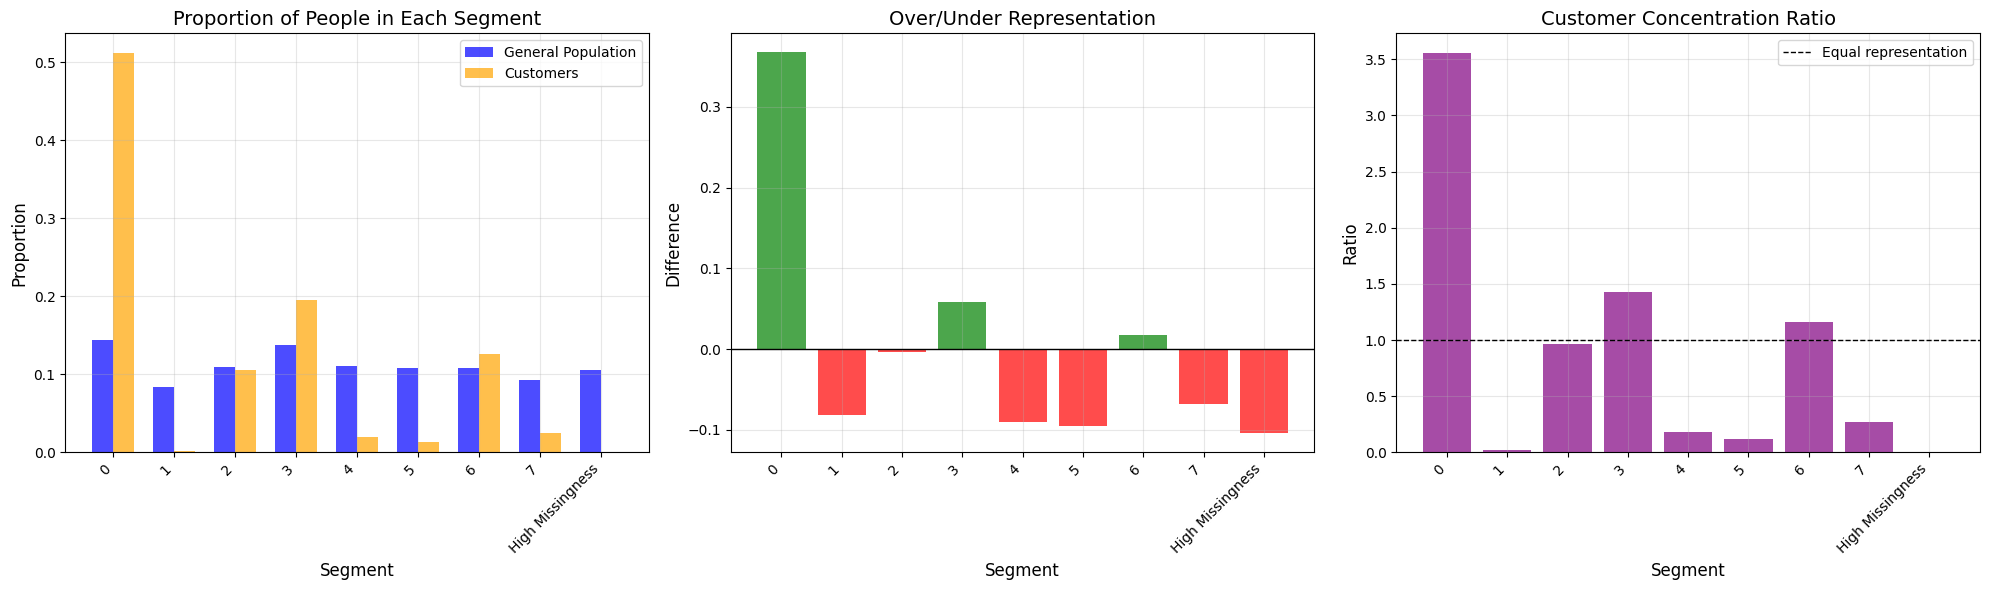


OVERREPRESENTED SEGMENTS (Target Audience):
  - 0: +36.7% more customers
  - 3: +5.9% more customers
  - 6: +1.8% more customers

UNDERREPRESENTED SEGMENTS (Not Interested):
  - 5: -9.6% fewer customers
  - 4: -9.0% fewer customers
  - 1: -8.2% fewer customers
  - 7: -6.8% fewer customers

 High Missingness segment: 0.01x less common in customers
  This segment may represent incomplete or unrepresentative data


In [89]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.

# Calculate proportions

print("INCLUDING HIGH-MISSINGNESS ROWS AS SEPARATE SEGMENT")

row_threshold = int(azdias.shape[1] * 0.3)
row_missing_count_azdias = azdias.isnull().sum(axis=1)

general_few_mask = row_missing_count_azdias <= row_threshold
general_many_mask = row_missing_count_azdias > row_threshold

general_few_count = general_few_mask.sum()
general_many_count = general_many_mask.sum()
general_total = len(azdias)

print(f"General population - Normal rows (≤{row_threshold} missing): {general_few_count:,} ({general_few_count/general_total*100:.1f}%)")
print(f"General population - High missingness rows: {general_many_count:,} ({general_many_count/general_total*100:.1f}%)")

customers_row_missing = customers_clean.isnull().sum(axis=1)
customers_few_mask = customers_row_missing <= row_threshold
customers_many_mask = customers_row_missing > row_threshold

customers_few_count = customers_few_mask.sum()
customers_many_count = customers_many_mask.sum()
customers_total = len(customers_clean)

print(f"Customers - Normal rows: {customers_few_count:,} ({customers_few_count/customers_total*100:.1f}%)")
print(f"Customers - High missingness rows: {customers_many_count:,} ({customers_many_count/customers_total*100:.1f}%)")


general_cluster_props = pd.Series(clusters_general).value_counts(normalize=True)
customer_cluster_props = pd.Series(clusters_customers).value_counts(normalize=True)

general_final_props = general_cluster_props * (general_few_count / general_total)
customer_final_props = customer_cluster_props * (customers_few_count / customers_total)

general_final_props['High Missingness'] = general_many_count / general_total
customer_final_props['High Missingness'] = customers_many_count / customers_total

general_final_props = general_final_props.reindex(list(range(8)) + ['High Missingness'])
customer_final_props = customer_final_props.reindex(list(range(8)) + ['High Missingness'])


comparison_final = pd.DataFrame({
    'General Population': general_final_props,
    'Customers': customer_final_props
})
comparison_final['Difference'] = comparison_final['Customers'] - comparison_final['General Population']
comparison_final['Ratio'] = comparison_final['Customers'] / comparison_final['General Population']

print(comparison_final.round(4))


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Proportion comparison
ax1 = axes[0]
x = np.arange(len(comparison_final))
width = 0.35
ax1.bar(x - width/2, comparison_final['General Population'], width, label='General Population', alpha=0.7, color='blue')
ax1.bar(x + width/2, comparison_final['Customers'], width, label='Customers', alpha=0.7, color='orange')
ax1.set_xlabel('Segment', fontsize=12)
ax1.set_ylabel('Proportion', fontsize=12)
ax1.set_title('Proportion of People in Each Segment', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_final.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Difference
ax2 = axes[1]
colors = ['green' if diff > 0 else 'red' for diff in comparison_final['Difference']]
ax2.bar(x, comparison_final['Difference'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Segment', fontsize=12)
ax2.set_ylabel('Difference', fontsize=12)
ax2.set_title('Over/Under Representation', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_final.index, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# 3. Ratio
ax3 = axes[2]
ax3.bar(x, comparison_final['Ratio'], color='purple', alpha=0.7)
ax3.axhline(y=1, color='black', linestyle='--', linewidth=1, label='Equal representation')
ax3.set_xlabel('Segment', fontsize=12)
ax3.set_ylabel('Ratio', fontsize=12)
ax3.set_title('Customer Concentration Ratio', fontsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(comparison_final.index, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find overrepresented clusters
overrepresented = comparison_final[comparison_final['Difference'] > 0].sort_values('Difference', ascending=False)
print("\nOVERREPRESENTED SEGMENTS (Target Audience):")
for segment in overrepresented.index:
    if segment != 'High Missingness':
        diff = overrepresented.loc[segment, 'Difference']
        print(f"  - {segment}: +{diff*100:.1f}% more customers")

# Find underrepresented clusters  
underrepresented = comparison_final[comparison_final['Difference'] < 0].sort_values('Difference', ascending=True)
print("\nUNDERREPRESENTED SEGMENTS (Not Interested):")
for segment in underrepresented.index[:5]:  # Top 5 most underrepresented
    if segment != 'High Missingness':
        diff = underrepresented.loc[segment, 'Difference']
        print(f"  - {segment}: {diff*100:.1f}% fewer customers")

# High missingness segment interpretation
high_missing_ratio = comparison_final.loc['High Missingness', 'Ratio']
if high_missing_ratio > 1:
    print(f"\n High Missingness segment: {high_missing_ratio:.2f}x more common in customers")
    print("  These customers have different data patterns that may require special handling")
elif high_missing_ratio < 1:
    print(f"\n High Missingness segment: {high_missing_ratio:.2f}x less common in customers")
    print("  This segment may represent incomplete or unrepresentative data")



### Discussion 3.3: Compare Customer Data to Demographics Data

(Double-click this cell and replace this text with your own text, reporting findings and conclusions from the clustering analysis. Can we describe segments of the population that are relatively popular with the mail-order company, or relatively unpopular with the company?)

 1. Primary Target Audience (Clusters 5 & 6): Young, environmentally conscious, financially prudent urbanites. The company should focus marketing efforts on digital channels, emphasize sustainability and value, and target renters and urban professionals.

2.  Secondary Target (Cluster 3):Affluent, property-owning urban families. This segment may respond well to premium product offerings and family-oriented messaging.

3. Avoid / Re-evaluate Strategy For: Clusters 0, 4, 7 – especially Cluster 7 (transient urban dwellers) and Cluster 4 (traditional conservatives). Either the product does not fit their needs, or alternative marketing channels are required to reach them effectively.
4. Key Insight: The company's strongest customer base is urban, mobile, and environmentally conscious, not traditional homeowners or rural populations. This suggests the company's products appeal to a modern, progressive demographic.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.

In [95]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?

# Find underrepresented clusters (negative difference)
underrepresented = comparison_final[comparison_final['Difference'] < 0]
underrepresented = underrepresented[underrepresented.index != 'High Missingness']
underrepresented = underrepresented.sort_values('Difference', ascending=True)

print("UNDERREPRESENTED CLUSTERS (Not Interested)")
if len(underrepresented) > 0:
    for cluster in underrepresented.index:
        diff = underrepresented.loc[cluster, 'Difference']
        ratio = underrepresented.loc[cluster, 'Ratio']
        print(f"\nCluster {int(cluster)}: {diff*100:.2f}% fewer customers (Ratio: {ratio:.2f}x)")
        
        # Analyze the cluster characteristics
        cluster_center_pca = kmeans.cluster_centers_[int(cluster)]
        cluster_center_original = pca.inverse_transform(cluster_center_pca.reshape(1, -1))
        cluster_center_original = scaler.inverse_transform(cluster_center_original)
        
        # Create profile
        cluster_profile = pd.DataFrame({
            'Feature': azdias.columns,
            'Value': cluster_center_original[0]
        })
        
        # Calculate deviation from average
        avg_values = azdias.mean().values
        cluster_profile['Deviation'] = (cluster_profile['Value'] - avg_values) / avg_values
        
        # Show top features with highest positive deviation
        print(f"\n  Characteristics of Cluster {int(cluster)} (compared to average):")
        top_features = cluster_profile.nlargest(5, 'Deviation')
        for _, row in top_features.iterrows():
            print(f"    - {row['Feature']}: {row['Deviation']*100:.1f}% above average")
else:
    print("  No underrepresented clusters found")
    
    

UNDERREPRESENTED CLUSTERS (Not Interested)

Cluster 5: -9.58% fewer customers (Ratio: 0.12x)

  Characteristics of Cluster 5 (compared to average):
    - KBA05_ANTG4: 157.2% above average
    - ANZ_HAUSHALTE_AKTIV: 122.0% above average
    - PLZ8_ANTG4: 116.4% above average
    - ANZ_HH_TITEL: 91.8% above average
    - PLZ8_BAUMAX: 85.1% above average

Cluster 4: -9.03% fewer customers (Ratio: 0.18x)

  Characteristics of Cluster 4 (compared to average):
    - SEMIO_TRADV: 58.7% above average
    - SEMIO_RAT: 54.1% above average
    - FINANZ_ANLEGER: 41.9% above average
    - FINANZ_SPARER: 41.1% above average
    - FINANZ_UNAUFFAELLIGER: 38.8% above average

Cluster 1: -8.16% fewer customers (Ratio: 0.02x)

  Characteristics of Cluster 1 (compared to average):
    - FINANZ_UNAUFFAELLIGER: 71.4% above average
    - FINANZ_ANLEGER: 64.2% above average
    - SEMIO_REL: 61.7% above average
    - SEMIO_KRIT: 44.1% above average
    - FINANZ_SPARER: 43.3% above average

Cluster 7: -6.78% fe

In [96]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?

# Find underrepresented clusters (negative difference)
# استبعاد 'High Missingness' من التحليل
underrepresented = comparison_final[comparison_final['Difference'] < 0]
underrepresented = underrepresented[underrepresented.index != 'High Missingness']
underrepresented = underrepresented.sort_values('Difference', ascending=True)

print("UNDERREPRESENTED CLUSTERS (Not Interested)")
if len(underrepresented) > 0:
    for cluster in underrepresented.index:
        diff = underrepresented.loc[cluster, 'Difference']
        ratio = underrepresented.loc[cluster, 'Ratio']
        print(f"\nCluster {int(cluster)}: {diff*100:.2f}% fewer customers (Ratio: {ratio:.2f}x)")
        
        # Analyze the cluster characteristics
        cluster_center_pca = kmeans.cluster_centers_[int(cluster)]
        cluster_center_original = pca.inverse_transform(cluster_center_pca.reshape(1, -1))
        cluster_center_original = scaler.inverse_transform(cluster_center_original)
        
        # Create profile
        cluster_profile = pd.DataFrame({
            'Feature': azdias.columns,
            'Value': cluster_center_original[0]
        })
        
        # Calculate deviation from average
        avg_values = azdias.mean().values
        cluster_profile['Deviation'] = (cluster_profile['Value'] - avg_values) / avg_values
        
        # Show top features with highest positive deviation
        print(f"\n  Characteristics of Cluster {int(cluster)} (compared to average):")
        top_features = cluster_profile.nlargest(5, 'Deviation')
        for _, row in top_features.iterrows():
            print(f"    - {row['Feature']}: {row['Deviation']*100:.1f}% above average")
else:
    print("  No underrepresented clusters found")
    
    

UNDERREPRESENTED CLUSTERS (Not Interested)

Cluster 5: -9.58% fewer customers (Ratio: 0.12x)

  Characteristics of Cluster 5 (compared to average):
    - KBA05_ANTG4: 157.2% above average
    - ANZ_HAUSHALTE_AKTIV: 122.0% above average
    - PLZ8_ANTG4: 116.4% above average
    - ANZ_HH_TITEL: 91.8% above average
    - PLZ8_BAUMAX: 85.1% above average

Cluster 4: -9.03% fewer customers (Ratio: 0.18x)

  Characteristics of Cluster 4 (compared to average):
    - SEMIO_TRADV: 58.7% above average
    - SEMIO_RAT: 54.1% above average
    - FINANZ_ANLEGER: 41.9% above average
    - FINANZ_SPARER: 41.1% above average
    - FINANZ_UNAUFFAELLIGER: 38.8% above average

Cluster 1: -8.16% fewer customers (Ratio: 0.02x)

  Characteristics of Cluster 1 (compared to average):
    - FINANZ_UNAUFFAELLIGER: 71.4% above average
    - FINANZ_ANLEGER: 64.2% above average
    - SEMIO_REL: 61.7% above average
    - SEMIO_KRIT: 44.1% above average
    - FINANZ_SPARER: 43.3% above average

Cluster 7: -6.78% fe

In [97]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

# Find overrepresented clusters (positive difference)
overrepresented = comparison_final[comparison_final['Difference'] > 0]
overrepresented = overrepresented[overrepresented.index != 'High Missingness']
overrepresented = overrepresented.sort_values('Difference', ascending=False)

print("OVERREPRESENTED CLUSTERS (Target Audience)")
if len(overrepresented) > 0:
    for cluster in overrepresented.index:
        diff = overrepresented.loc[cluster, 'Difference']
        ratio = overrepresented.loc[cluster, 'Ratio']
        print(f"\nCluster {int(cluster)}: +{diff*100:.2f}% more customers (Ratio: {ratio:.2f}x)")
        
        # Analyze the cluster characteristics
        cluster_center_pca = kmeans.cluster_centers_[int(cluster)]
        cluster_center_original = pca.inverse_transform(cluster_center_pca.reshape(1, -1))
        cluster_center_original = scaler.inverse_transform(cluster_center_original)
        
        # Create profile
        cluster_profile = pd.DataFrame({
            'Feature': azdias.columns,
            'Value': cluster_center_original[0]
        })
        
        # Calculate deviation from average
        avg_values = azdias.mean().values
        cluster_profile['Deviation'] = (cluster_profile['Value'] - avg_values) / avg_values
        
        # Show top features with highest positive deviation
        print(f"\n  Characteristics of Cluster {int(cluster)} (compared to average):")
        top_features = cluster_profile.nlargest(5, 'Deviation')
        for _, row in top_features.iterrows():
            print(f"    - {row['Feature']}: {row['Deviation']*100:.1f}% above average")
else:
    print("  No overrepresented clusters found")

OVERREPRESENTED CLUSTERS (Target Audience)

Cluster 0: +36.74% more customers (Ratio: 3.55x)

  Characteristics of Cluster 0 (compared to average):
    - GREEN_AVANTGARDE: 80.6% above average
    - KBA05_ANTG1: 63.0% above average
    - FINANZ_MINIMALIST: 51.5% above average
    - SEMIO_VERT: 50.8% above average
    - Youth_Movement: 37.4% above average

Cluster 3: +5.85% more customers (Ratio: 1.43x)

  Characteristics of Cluster 3 (compared to average):
    - GREEN_AVANTGARDE: 85.6% above average
    - KBA05_ANTG1: 63.0% above average
    - SEMIO_ERL: 43.5% above average
    - Youth_Movement: 36.5% above average
    - MOBI_REGIO: 35.3% above average

Cluster 6: +1.78% more customers (Ratio: 1.16x)

  Characteristics of Cluster 6 (compared to average):
    - ANZ_HH_TITEL: 86.6% above average
    - KBA05_ANTG4: 83.8% above average
    - KBA05_ANTG3: 76.3% above average
    - ANZ_HAUSHALTE_AKTIV: 71.2% above average
    - PLZ8_ANTG4: 68.1% above average
